### 주피터 노트북 실행환경

1. 분석 환경 의존성 추가

    ```
    poetry lock
    poetry install --with analysis
    ```

2. 이후 Jupyter 커널 등록

    ```
    poetry run python -m ipykernel install --user --name seoul-walk --display-name "seoul-walk (Poetry)"
    ```

3. jupyter notebook 세션 선택 시 poetry venv 경로로 선택

In [ ]:
# jupyter notebook 세션 확인하기
# Poetry venv 경로가 나오면 정상
import sys
print(sys.executable)

c:\Users\dygim\AppData\Local\pypoetry\Cache\virtualenvs\seoul-walk-platform-D_JI-aCK-py3.11\Scripts\python.exe


In [ ]:
# 1. Setup

# 분석에 필요한 라이브러리 불러오기
import os, sys

# 프로젝트 루트를 sys.path에 추가해 src 패키지 import
sys.path.insert(0, os.path.abspath("../"))

import yaml
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
from dotenv import load_dotenv
from sqlalchemy import create_engine, text

# 한글 폰트 설정 및 '-' 기호 깨짐 방지
matplotlib.rcParams["font.family"] = "Malgun Gothic"
matplotlib.rcParams["axes.unicode_minus"] = False

# .env에서 DB 접속 정보 로드
load_dotenv(encoding="utf-8")
DATABASE_URL = (
    f"postgresql+psycopg2://{os.getenv('POSTGRES_USER')}:{os.getenv('POSTGRES_PASSWORD')}"
    f"@{os.getenv('POSTGRES_HOST')}:{os.getenv('POSTGRES_PORT')}/{os.getenv('POSTGRES_DB')}?client_encoding=utf8"
)
engine = create_engine(DATABASE_URL, pool_pre_ping=True)

# 분석 결과 이미지 저장 디렉토리
FIGURES_DIR = "../figures"
os.makedirs(FIGURES_DIR, exist_ok=True)

In [ ]:
# 2. 레이어별 총 개수

# 5개 레이어 테이블 각각의 전체 row 수를 UNION ALL로 한번에 집계
# 레이어 간 데이터 규모 차이 파악 → 비율 계산과 시각화의 기반 데이터
# UNION ALL은 여러 SELECT 결과를 그대로 이어붙이는 역할
layer_count_sql = """
SELECT layer, count FROM (
    SELECT 'child_layer'    AS layer, COUNT(*) AS count FROM child_layer    UNION ALL
    SELECT 'safety_layer'   AS layer, COUNT(*) AS count FROM safety_layer   UNION ALL
    SELECT 'nature_layer'   AS layer, COUNT(*) AS count FROM nature_layer   UNION ALL
    SELECT 'landmark_layer' AS layer, COUNT(*) AS count FROM landmark_layer UNION ALL
    SELECT 'running_layer'  AS layer, COUNT(*) AS count FROM running_layer
) t ORDER BY count DESC
"""
layer_counts = pd.read_sql(text(layer_count_sql), engine)
layer_counts

,layer,count
0,safety_layer,58209
1,nature_layer,6516
2,child_layer,1184
3,landmark_layer,658
4,running_layer,225


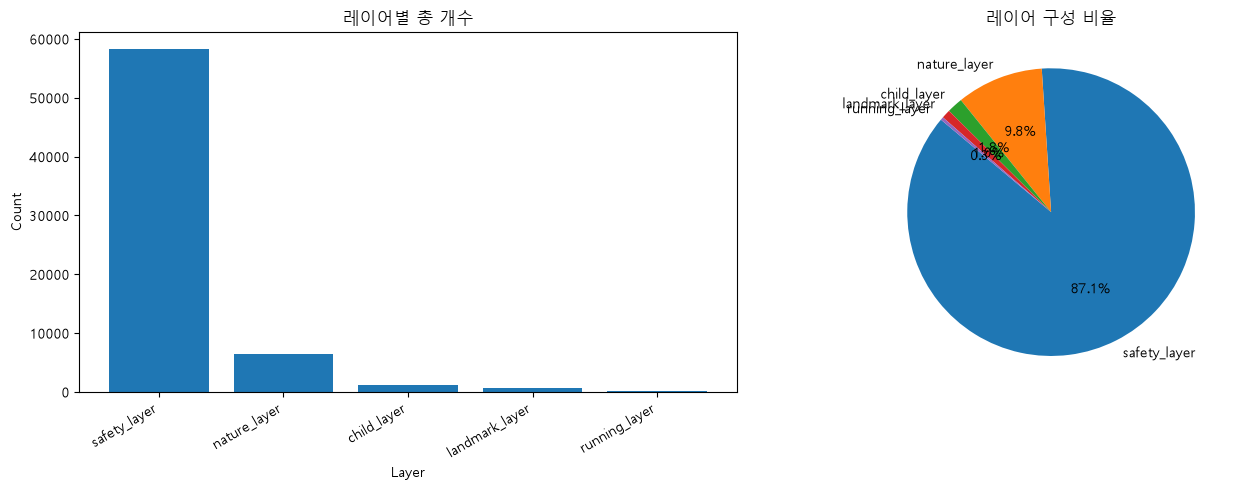

In [ ]:
# 3. 레이어별 총 개수 막대그래프 + 파이차트

# 2번에서 집계한 결과의 시각화 버전
# 레이어 간 데이터 편중 여부 파악 가능
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 막대그래프
axes[0].bar(layer_counts["layer"], layer_counts["count"])
axes[0].set_title("레이어별 총 개수")
axes[0].set_xlabel("Layer")
axes[0].set_ylabel("Count")
plt.setp(axes[0].get_xticklabels(), rotation=30, ha="right")

# 파이차트
axes[1].pie(layer_counts["count"], labels=layer_counts["layer"], autopct="%1.1f%%", startangle=140)
axes[1].set_title("레이어 구성 비율")

plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/layer_count_and_ratio.png", dpi=150)
plt.show()

In [ ]:
# 4. 중복 탐지

# 각 레이어에서 key 컬럼(이름+좌표 또는 타입+FK) 조합이 중복된 행 검색
dup_queries = {
    "child_layer":    "SELECT category, ST_AsText(geom) g, COUNT(*) cnt FROM child_layer GROUP BY 1,2 HAVING COUNT(*)>1",
    "safety_layer":   "SELECT safety_type, ST_AsText(geom) g, COUNT(*) cnt FROM safety_layer GROUP BY 1,2 HAVING COUNT(*)>1",
    "nature_layer":   "SELECT green_type, osm_raw_id, COUNT(*) cnt FROM nature_layer GROUP BY 1,2 HAVING COUNT(*)>1",
    "landmark_layer": "SELECT name, ST_AsText(geom) g, COUNT(*) cnt FROM landmark_layer GROUP BY 1,2 HAVING COUNT(*)>1",
    "running_layer":  "SELECT name, course_type, COUNT(*) cnt FROM running_layer GROUP BY 1,2 HAVING COUNT(*)>1",
}

dup_summary = []
for layer, sql in dup_queries.items():
    df = pd.read_sql(text(sql), engine)
    dup_summary.append({
        "layer": layer,
        "중복 그룹 수": len(df),
        "중복 행 수": int(df["cnt"].sum()) if len(df) > 0 else 0,
    })

pd.DataFrame(dup_summary)

,layer,중복 그룹 수,중복 행 수
0,child_layer,0,0
1,safety_layer,6320,19381
2,nature_layer,0,0
3,landmark_layer,0,0
4,running_layer,6,21


In [ ]:
# 5. raw 범주별 분포

# 각 layer row가 어떤 raw 소스에서 유입됐는지 FK 기준으로 집계
# child_layer: csv_raw vs public_raw
child_raw = pd.read_sql(text("""
    SELECT CASE WHEN csv_raw_id IS NOT NULL THEN 'csv_raw(보호구역)'
                WHEN public_raw_id IS NOT NULL THEN 'public_raw(놀이시설)'
                ELSE 'unknown' END AS raw_source,
           COUNT(*) AS count
    FROM child_layer GROUP BY 1
"""), engine)
child_raw["layer"] = "child_layer"

# safety_layer: safety_type으로 구분
safety_raw = pd.read_sql(text("""
    SELECT safety_type AS raw_source, COUNT(*) AS count
    FROM safety_layer GROUP BY 1
"""), engine)
safety_raw["layer"] = "safety_layer"

# nature_layer: 전부 osm_raw, green_type으로 구분
nature_raw = pd.read_sql(text("""
    SELECT COALESCE(green_type, 'unknown') AS raw_source, COUNT(*) AS count
    FROM nature_layer GROUP BY 1 ORDER BY count DESC
"""), engine)
nature_raw["layer"] = "nature_layer"

# running_layer: course_type으로 구분
running_raw = pd.read_sql(text("""
    SELECT course_type AS raw_source, COUNT(*) AS count
    FROM running_layer GROUP BY 1
"""), engine)
running_raw["layer"] = "running_layer"

# landmark_layer: raw FK 없음 — TourAPI 단일 소스
landmark_raw = pd.DataFrame([{"raw_source": "public_raw(TourAPI)", "count": layer_counts.loc[layer_counts["layer"]=="landmark_layer","count"].values[0], "layer": "landmark_layer"}])

raw_dist = pd.concat([child_raw, safety_raw, nature_raw, running_raw, landmark_raw], ignore_index=True)
raw_dist

,raw_source,count,layer
0,csv_raw(보호구역),1184,child_layer
1,accident_zone,132,safety_layer
2,cctv,57760,safety_layer
3,streetlight,317,safety_layer
4,park,2205,nature_layer
5,grass,1714,nature_layer
6,wood,1011,nature_layer
7,garden,955,nature_layer
8,forest,394,nature_layer
9,farmland,111,nature_layer


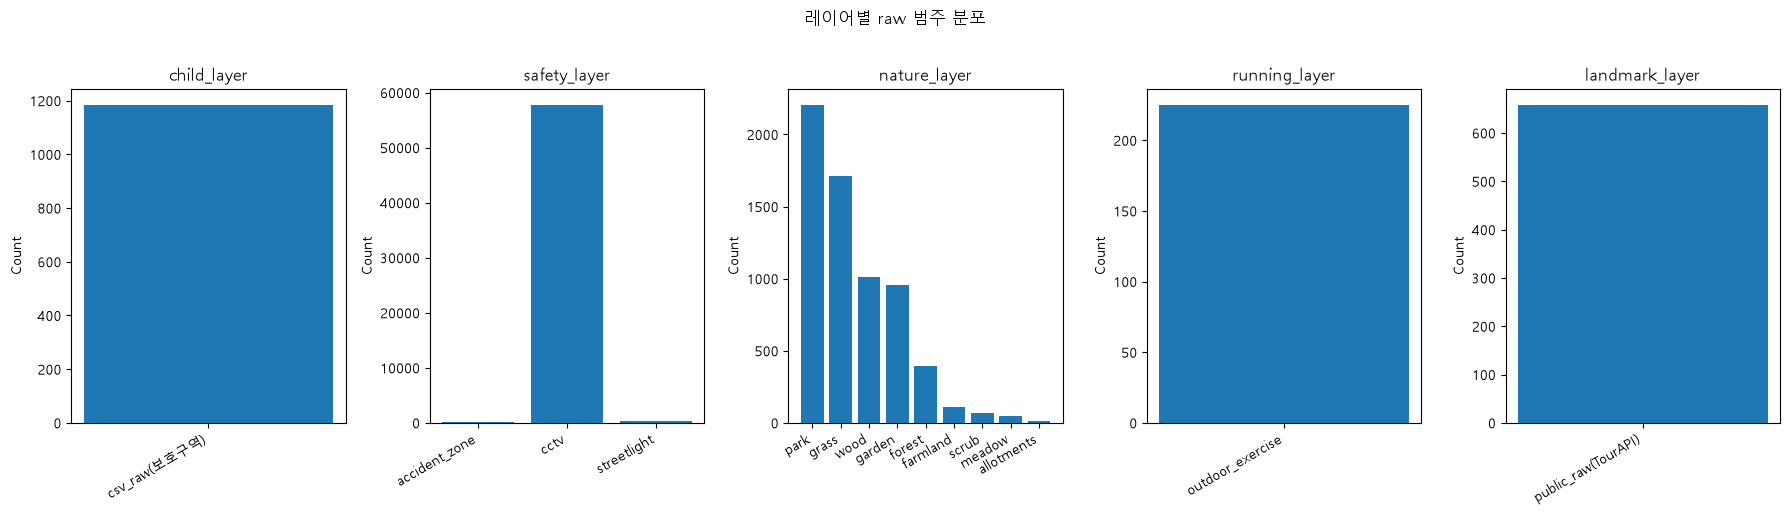

In [ ]:
# 6. raw 범주별 분포 시각화

# 5번에서 집계한 결과를 시각화
layers = raw_dist["layer"].unique()
fig, axes = plt.subplots(1, len(layers), figsize=(18, 5))

for ax, layer in zip(axes, layers):
    df = raw_dist[raw_dist["layer"] == layer]
    ax.bar(df["raw_source"], df["count"])
    ax.set_title(layer)
    ax.set_ylabel("Count")
    plt.setp(ax.get_xticklabels(), rotation=30, ha="right")

plt.suptitle("레이어별 raw 범주 분포", y=1.02)
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/layer_raw_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

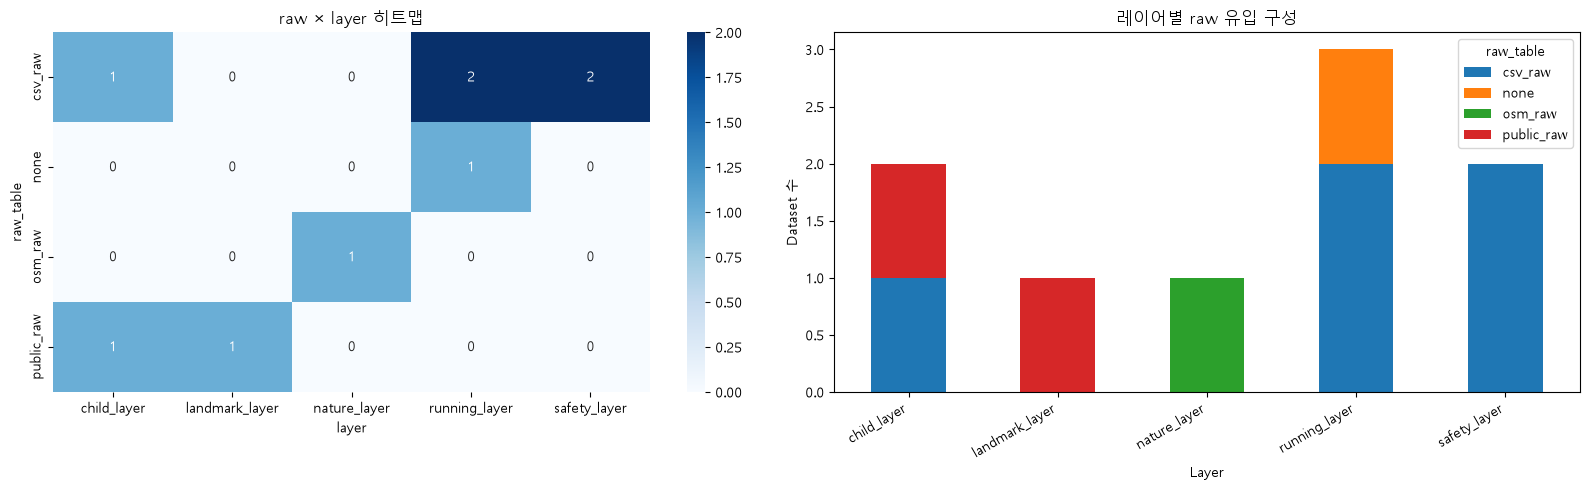

In [ ]:
# 7. raw × layer 크로스탭 (registry.yaml 기반)

# registry.yaml 파일 열기
with open("../../src/data/registry.yaml", "r", encoding="utf-8") as f:
    registry = yaml.safe_load(f)

rows = [
    {"dataset": k, "raw_table": v.get("raw_table","none"), "layer": v.get("layer")}
    for k, v in registry["datasets"].items()
    if v.get("approved") and v.get("layer") not in [None, "walk_nodes_and_walk_edges"]
]
registry_df = pd.DataFrame(rows)
crosstab = pd.crosstab(registry_df["raw_table"], registry_df["layer"])

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# 히트맵
sns.heatmap(crosstab, annot=True, fmt="d", cmap="Blues", ax=axes[0])
axes[0].set_title("raw × layer 히트맵")

# 누적 막대그래프
crosstab.T.plot(kind="bar", stacked=True, ax=axes[1])
axes[1].set_title("레이어별 raw 유입 구성")
axes[1].set_xlabel("Layer")
axes[1].set_ylabel("Dataset 수")
plt.setp(axes[1].get_xticklabels(), rotation=30, ha="right")

plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/raw_layer_crosstab.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
# 8. 레이어 내 빈도 상위 N개 항목

TOP_N = 10

top_queries = {
    "child_layer(category)":    "SELECT category AS item, COUNT(*) cnt FROM child_layer GROUP BY 1 ORDER BY cnt DESC LIMIT {}".format(TOP_N),
    "safety_layer(safety_type)":"SELECT safety_type AS item, COUNT(*) cnt FROM safety_layer GROUP BY 1 ORDER BY cnt DESC LIMIT {}".format(TOP_N),
    "nature_layer(green_type)": "SELECT COALESCE(green_type,'unknown') AS item, COUNT(*) cnt FROM nature_layer GROUP BY 1 ORDER BY cnt DESC LIMIT {}".format(TOP_N),
    "running_layer(course_type)":"SELECT course_type AS item, COUNT(*) cnt FROM running_layer GROUP BY 1 ORDER BY cnt DESC LIMIT {}".format(TOP_N),
}

for title, sql in top_queries.items():
    df = pd.read_sql(text(sql), engine)
    print(f"\n▶ {title}")
    display(df)


▶ child_layer(category)


,item,cnt
0,어린이보호구역,1184



▶ safety_layer(safety_type)


,item,cnt
0,cctv,57760
1,streetlight,317
2,accident_zone,132



▶ nature_layer(green_type)


,item,cnt
0,park,2205
1,grass,1714
2,wood,1011
3,garden,955
4,forest,394
5,farmland,111
6,scrub,70
7,meadow,46
8,allotments,10



▶ running_layer(course_type)


,item,cnt
0,outdoor_exercise,225
